In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [126]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
train_df.shape
test_df.shape
train_df.head(2)

(7000, 26)

(1124, 25)

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e


In [127]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

In [128]:
train_df['mushroom_id'] = train_df['mushroom_id'].astype(object)
train_df['ID'] = train_df['mushroom_id'].astype(object)
train_df['mushroom_id'].dtypes
train_df['ID'].dtypes

dtype('O')

dtype('O')

In [129]:
train_df.describe()

,number_of_bruises,ring-number
count,7000.000000,6964.000000
mean,5.459571,1.080988
std,7.723528,0.272836
min,0.000000,1.000000
25%,0.000000,1.000000
50%,0.000000,1.000000
75%,11.000000,1.000000
max,24.000000,2.000000


In [130]:
num_cols = ['number_of_bruises', 'ring-number']
cat_cols = list(train_df.drop(columns=num_cols).columns)

In [131]:
train_df.isna().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3236
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

In [132]:
before = len(train_df)
train_df = train_df.drop_duplicates()
print(f"Duplicates removed: {before - len(train_df)}")
print(f"Shape after: {train_df.shape}")

Duplicates removed: 0
Shape after: (7000, 26)


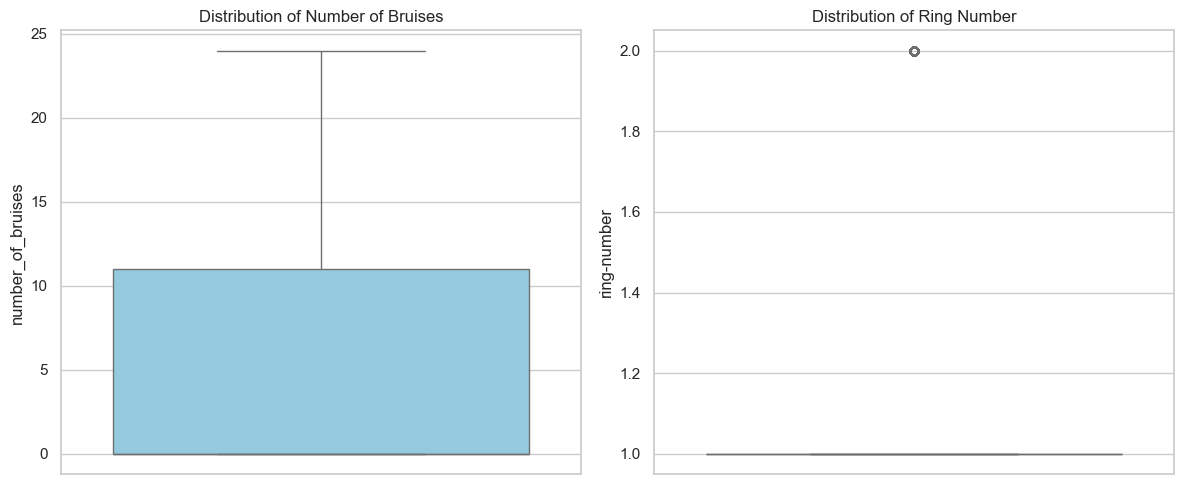

In [133]:
# Create a figure with two subplots
fig = plt.figure(figsize=(12, 5))

# Plot for number_of_bruises
_ = plt.subplot(1, 2, 1)
_ = sns.boxplot(y=train_df['number_of_bruises'], color='skyblue')
_ = plt.title('Distribution of Number of Bruises')

# Plot for ring-number
_ = plt.subplot(1, 2, 2)
_ = sns.boxplot(y=train_df['ring-number'], color='salmon')
_ = plt.title('Distribution of Ring Number')

plt.tight_layout()

<Axes: xlabel='habitat', ylabel='count'>

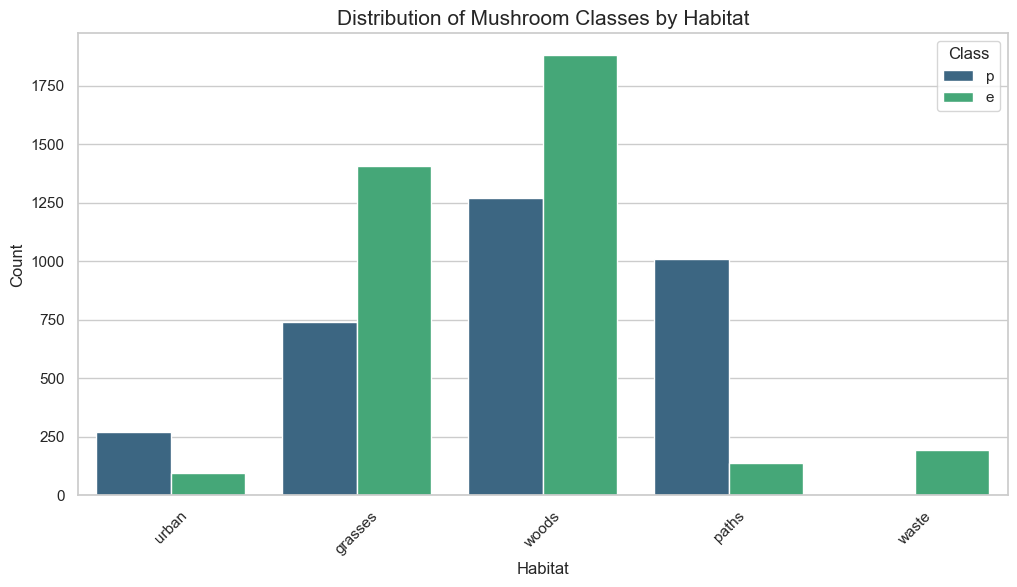

In [ ]:
_ = plt.figure(figsize=(12, 6))

sns.countplot(data=train_df, x='habitat', hue='class', palette='viridis')

_ = plt.title('Distribution of Mushroom Classes by Habitat', fontsize=15)
_ = plt.xlabel('Habitat', fontsize=12)
_ = plt.ylabel('Count', fontsize=12)
_ = plt.legend(title='Class', loc='upper right')

# Rotate x-axis labels if they overlap
_ = plt.xticks(rotation=45)

Woods are the most frequent habitat: This habitat contains the highest volume of mushrooms for both edible (e) and poisonous (p) classes, though edible mushrooms significantly outnumber poisonous ones here.

Safe Havens: The waste habitat is unique as it contains exclusively edible mushrooms (according to this sample), while grasses also show a clear preference toward edible varieties.

High-Risk Areas: In urban and paths habitats, poisonous mushrooms are much more prevalent than edible ones. If you find a mushroom on a path, it is statistically much more likely to be poisonous.

Predictive Strength: The strong variation in class distribution across different habitats suggests that habitat is a highly informative feature for distinguishing between edible and poisonous mushrooms.

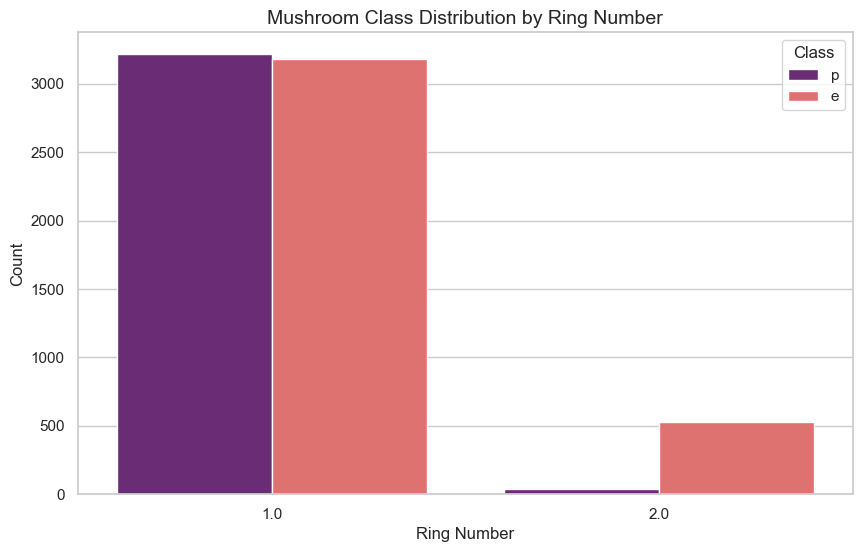

In [135]:
_ = plt.figure(figsize=(10, 6))

# Create the count plot for 'ring-number' grouped by 'class'
_ = sns.countplot(data=train_df, x='ring-number', hue='class', palette='magma')

_ = plt.title('Mushroom Class Distribution by Ring Number', fontsize=14)
_ = plt.xlabel('Ring Number', fontsize=12)
_ = plt.ylabel('Count', fontsize=12)
_ = plt.legend(title='Class')

In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

In [137]:
X = train_df.drop(columns=['class'])
y = train_df['class']

num_features = num_cols
cat_features = [col for col in X.columns if col not in num_cols + ['ID', 'mushroom_id']]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [139]:
X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (5600, 99)
X_val shape: (1400, 99)


In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [141]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(probability=True),
    "K-Neighbors": KNeighborsClassifier()
}

In [142]:
results = {}

for name, model in models.items():
  # Train
  model.fit(X_train, y_train)
  # Predict
  y_pred = model.predict(X_val)
  # Evaluate
  acc = accuracy_score(y_val, y_pred)
  results[name] = acc
  print(f"{name}: Accuracy = {acc:.4f}")

LogisticRegression(max_iter=1000)

Logistic Regression: Accuracy = 1.0000


DecisionTreeClassifier()

Decision Tree: Accuracy = 1.0000


RandomForestClassifier()

...

AdaBoost: Accuracy = 0.9943


SVC(probability=True)

SVM: Accuracy = 1.0000


KNeighborsClassifier()

K-Neighbors: Accuracy = 1.0000


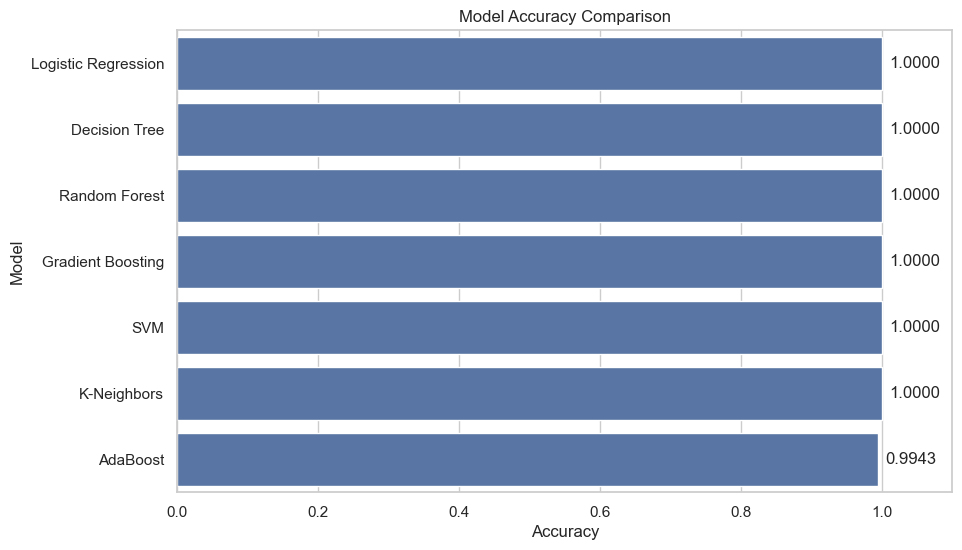

In [145]:
# Convert results to a DataFrame for easy plotting
res_df = pd.DataFrame(list(results.items()), columns=[
                      'Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

_ = plt.figure(figsize=(10, 6))
_ = sns.barplot(x='Accuracy', y='Model', data=res_df)
_ = plt.title('Model Accuracy Comparison')
_ = plt.xlim(0, 1.1)  # Set limit slightly above 1 for text padding
for i, val in enumerate(res_df['Accuracy']):
  _ = plt.text(val + 0.01, i, f"{val:.4f}", va='center')

In [152]:
from sklearn.model_selection import GridSearchCV

# Define the models and their respective parameter grids
param_grids = {
    "Gradient Boosting": {
        'model': GradientBoostingClassifier(),
        'params': {
            'n_estimators': [100],
            'learning_rate': [0.1, 0.2],
        }
    },
    "Random Forest": {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [100],
            'max_depth': [10]
        }
    },
    "SVM": {
        'model': SVC(probability=True),
        'params': {
            'C': [0.1, 1],
            'kernel': ['rbf', 'poly'],
        }
    }
}

In [147]:
best_tuned_models = {}

for name, config in param_grids.items():
  print(f"Tuning {name}...")

  grid_search = GridSearchCV(
      estimator=config['model'],
      param_grid=config['params'],
      cv=5,            # 5-fold cross-validation
      scoring='accuracy',
      n_jobs=-1        # Use all available CPU cores
  )

  grid_search.fit(X_train, y_train)

  # Store the best model and print results
  best_tuned_models[name] = grid_search.best_estimator_
  print(f"Best Params for {name}: {grid_search.best_params_}")
  print(f"Best CV Score: {grid_search.best_score_:.4f}\n")

Tuning Gradient Boosting...


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

Best Params for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Best CV Score: 1.0000

Tuning Random Forest...


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

Best Params for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 1.0000

Tuning SVM...


GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'poly']},
             scoring='accuracy')

Best Params for SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'poly'}
Best CV Score: 1.0000



In [148]:
for name, model in best_tuned_models.items():
  y_val_pred = model.predict(X_val)
  tuned_acc = accuracy_score(y_val, y_val_pred)
  print(f"Tuned {name} Validation Accuracy: {tuned_acc:.4f}")

Tuned Gradient Boosting Validation Accuracy: 1.0000
Tuned Random Forest Validation Accuracy: 1.0000
Tuned SVM Validation Accuracy: 1.0000


In [151]:
# 1. Transform the test data
X_test_processed = preprocessor.transform(test_df)

# 2. Predict using best model
best_model = models["Gradient Boosting"]
test_predictions = best_model.predict(X_test_processed)

# 3. Inverse transform the labels back to 'e' and 'p'
final_labels = le.inverse_transform(test_predictions)

# 4. Save to a CSV for submission
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'class': final_labels
})

print(submission.head())
submission.to_csv('submission.csv', index=False)

   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e
